# Cost-Model A/B Demo

This notebook runs `BacktestEngine` twice on the same synthetic
universe — once with the legacy flat-rate `transaction_cost`
(10 bps round-trip) and once with bt 1.2.0's
`AlmgrenChrissCostModel` — and compares headline metrics, equity
curves, cumulative fees, and the response to thinning liquidity.

**Why synthetic?** The engine accepts a long-format price
DataFrame directly, so we can run end-to-end with no FMP API key,
no SQLite seed, and no on-disk artefacts.

**Minimum to run on real data**
1. `pip install -r requirements.txt` (bt>=1.2 is required for the
   cost-model API).
2. Optional: `FMP_API_KEY` in `.env` for fresh downloads. Without
   it the engine reads from the cached SQLite DB at
   `$DATA_BASE_DIR/finrl_trading.db` (default `./data`).
3. Volume comes from the `cshtrd` column already in
   `price_data`; volatility is computed on-the-fly by the engine
   as a 20-day rolling stdev of log adj_close — no extra fetcher
   work needed.


In [1]:
import sys
from pathlib import Path

import bt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if (Path.cwd().name == 'examples') else Path.cwd()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'src'))

from src.backtest.backtest_engine import BacktestConfig, BacktestEngine

%matplotlib inline
np.random.seed(42)
print('bt version:', bt.__version__)


project_root: /mnt/d/work/FinRL-Trading
project_root: /mnt/d/work/FinRL-Trading
bt version: 1.2.0


## Synthetic universe

15 tickers, ~3 years of business-day prices on a geometric random
walk, log-normal volume averaging ~25M shares — typical large-cap
liquidity. The engine consumes this in long format
(`datadate`, `tic`, `adj_close`, `cshtrd`, ...).


In [2]:
tickers = [f'S{i:02d}' for i in range(15)]
start, end = '2020-01-02', '2022-12-30'
rng = np.random.default_rng(42)
dates = pd.bdate_range(start, end)
n_days, n_tic = len(dates), len(tickers)

mu = rng.uniform(0.04, 0.12, n_tic) / 252
sigma = rng.uniform(0.15, 0.45, n_tic) / np.sqrt(252)
rets = rng.standard_normal((n_days, n_tic)) * sigma + mu
prices = 100.0 * np.exp(rets.cumsum(axis=0))
volumes = rng.lognormal(np.log(2.5e7), 0.3, size=(n_days, n_tic))

rows = []
for i, dt in enumerate(dates):
    for j, t in enumerate(tickers):
        p = float(prices[i, j])
        rows.append({
            'datadate': dt, 'tic': t, 'gvkey': t,
            'prcod': p, 'prchd': p * 1.005, 'prcld': p * 0.995,
            'prccd': p, 'adj_close': p,
            'cshtrd': float(volumes[i, j]),
        })
long_prices = pd.DataFrame(rows)

wide = long_prices.pivot(index='datadate', columns='tic', values='adj_close')
weights = pd.DataFrame(1.0 / n_tic, index=wide.index[::21], columns=wide.columns)
print(f'{n_tic} tickers, {n_days} days, {len(weights)} rebalances')


15 tickers, 782 days, 38 rebalances


## Two engine configurations

Both runs share initial capital ($1B), data, and weight signals.
The only difference is the cost model:

* **legacy_flat_10bps** — `commissions=lambda q,p: |q|*p*0.0010`
  (10 bps round-trip flat fee; this is the existing engine path).
* **almgren_chriss** — `commissions=AlmgrenChrissCostModel(
  alpha=1, beta=1, epsilon=0.0005)` plus auto-built volume +
  rolling-volatility frames.

We bypass `engine.run_backtest` and reach for `_build_bt_backtest`
directly so we can pull `strategy.fees` and `security.outlays` out
of the bt result for richer plots.


In [3]:
common = dict(
    start_date=start, end_date=end, rebalance_freq='M',
    initial_capital=1_000_000_000.0,
    benchmark_tickers=[],
    integer_positions=False,  # bt allocator can't converge at $1B
)

def make_engine_and_bt(label, cost_model=None, **extra):
    cfg = BacktestConfig(transaction_cost=0.0010,
                          cost_model=cost_model, **common, **extra)
    eng = BacktestEngine(cfg)
    price_wide = eng._prepare_price_data_for_bt(long_prices.copy())
    ws = weights.reindex(price_wide.index).ffill().fillna(0.0)
    strat = eng._create_bt_strategy(label, ws)
    bkt = eng._build_bt_backtest(strat, price_wide, long_prices)
    return bkt

legacy_bkt = make_engine_and_bt('legacy_flat_10bps')
ac_bkt = make_engine_and_bt('almgren_chriss',
    cost_model=bt.AlmgrenChrissCostModel(alpha=1.0, beta=1.0,
                                         epsilon=0.0005))

result = bt.run(legacy_bkt, ac_bkt)
result.display()


Stat                 legacy_flat_10bps    almgren_chriss
-------------------  -------------------  ----------------
Start                2020-01-01           2020-01-01
End                  2022-12-30           2022-12-30
Risk-free rate       0.00%                0.00%

Total Return         36.20%               36.97%
Daily Sharpe         1.24                 1.26
Daily Sortino        1.94                 1.98
CAGR                 10.87%               11.08%
Max Drawdown         -11.91%              -11.85%
Calmar Ratio         0.91                 0.93

MTD                  3.03%                3.04%
3m                   4.20%                4.25%
6m                   3.76%                3.85%
YTD                  13.33%               13.54%
1Y                   13.84%               14.05%
3Y (ann.)            10.87%               11.08%
5Y (ann.)            -                    -
10Y (ann.)           -                    -
Since Incep. (ann.)  10.87%               11.08%

Daily Shar

## Headline metrics

Pull fees and traded notional from the bt strategy / security
objects; *fees per traded* is the effective bps the strategy paid.


In [4]:
def summarise(bkt, label):
    fees_total = float(bkt.strategy.fees.sum())
    final_value = float(bkt.strategy.values.iloc[-1])
    initial_capital = common['initial_capital']
    traded_notional = sum(abs(sec.outlays).sum()
                          for sec in bkt.strategy.securities)
    return {
        'strategy': label,
        'final_equity_$M': final_value / 1e6,
        'total_return_%': 100 * (final_value / initial_capital - 1),
        'gross_traded_$B': traded_notional / 1e9,
        'total_fees_$M': fees_total / 1e6,
        'fees_per_traded_bps': 1e4 * fees_total / max(traded_notional, 1.0),
    }

summary = pd.DataFrame([
    summarise(legacy_bkt, 'legacy_flat_10bps'),
    summarise(ac_bkt, 'almgren_chriss'),
]).set_index('strategy')
summary


,final_equity_$M,total_return_%,gross_traded_$B,total_fees_$M,fees_per_traded_bps
strategy,,,,,
legacy_flat_10bps,1362.031452,36.203145,14.022595,14.022595,10.000000
almgren_chriss,1369.727973,36.972797,14.063211,7.729719,5.496411


## Equity curves

The realistic-cost run sits below the legacy curve when the
epsilon term + impact exceeds the legacy 10 bps; in this regime
the AC default's 5 bps spread plus modest impact is *cheaper*
than 10 bps flat, so the AC equity curve sits *above* legacy.
Direction reverses if you crank participation by thinning volume
(see the sensitivity sweep below).


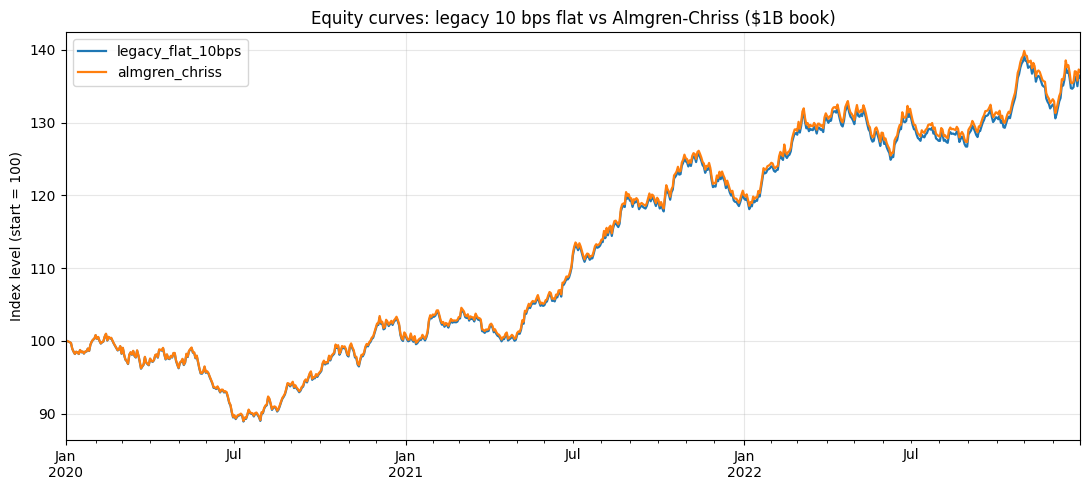

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
result.prices.plot(ax=ax, lw=1.6)
ax.set_title('Equity curves: legacy 10 bps flat vs Almgren-Chriss ($1B book)')
ax.set_ylabel('Index level (start = 100)')
ax.grid(alpha=0.3)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


## Cumulative fees over time

`strategy.fees` is the per-day fee the cost model charged. Its
cumulative sum gives total cost paid from inception. Steps line
up with rebalance dates.


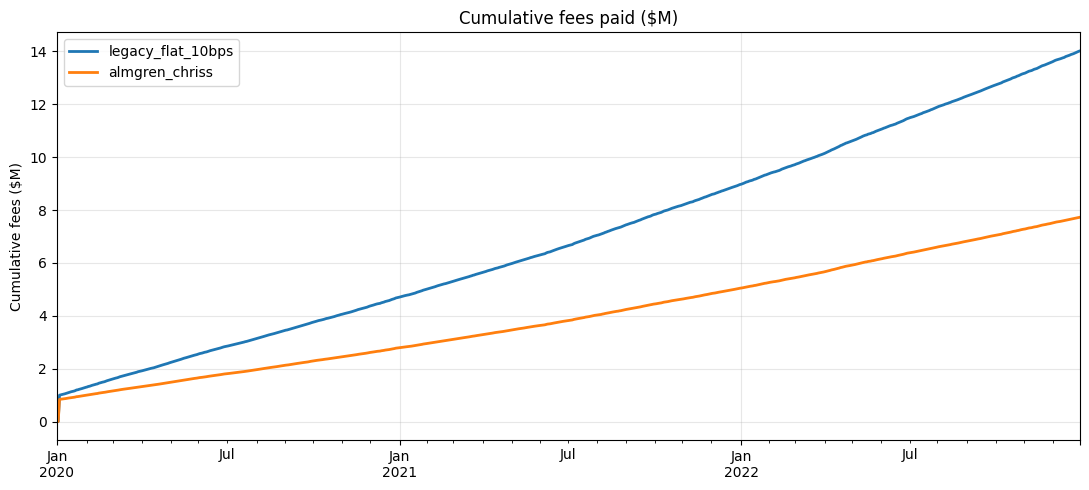

In [6]:
fees_legacy = legacy_bkt.strategy.fees.cumsum() / 1e6
fees_ac = ac_bkt.strategy.fees.cumsum() / 1e6

fig, ax = plt.subplots(figsize=(11, 5))
fees_legacy.plot(ax=ax, lw=2.0, label='legacy_flat_10bps')
fees_ac.plot(ax=ax, lw=2.0, label='almgren_chriss', color='tab:orange')
ax.set_title('Cumulative fees paid ($M)')
ax.set_ylabel('Cumulative fees ($M)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Sensitivity to liquidity (volume sweep)

The AC permanent and depth components scale linearly in `|q|/V`,
so halving available volume doubles the participation rate and
the impact terms grow accordingly. A flat-rate cost is
indifferent. We synthesise this by scaling the volume frame and
running the AC engine repeatedly.


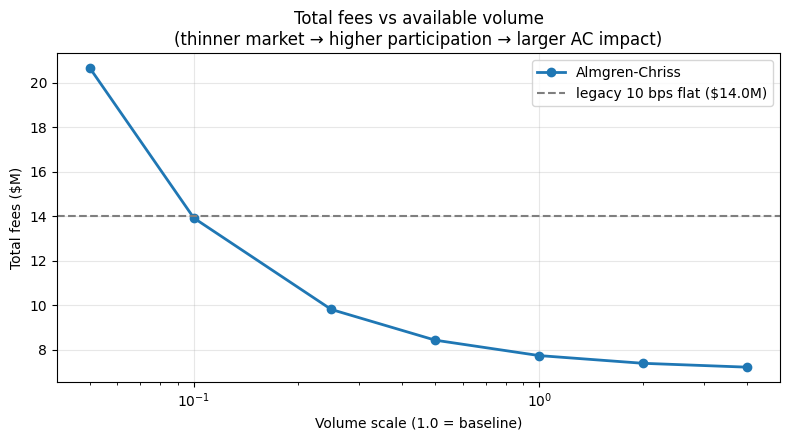

In [7]:
scales = [0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0]
ac_fees, legacy_fees = [], []
for s in scales:
    long_scaled = long_prices.copy()
    long_scaled['cshtrd'] = long_scaled['cshtrd'] * s
    cfg = BacktestConfig(
        transaction_cost=0.0010,
        cost_model=bt.AlmgrenChrissCostModel(alpha=1.0, beta=1.0,
                                              epsilon=0.0005),
        **common,
    )
    eng = BacktestEngine(cfg)
    price_wide = eng._prepare_price_data_for_bt(long_scaled.copy())
    ws = weights.reindex(price_wide.index).ffill().fillna(0.0)
    strat = eng._create_bt_strategy(f'AC_V_x_{s}', ws)
    bkt = eng._build_bt_backtest(strat, price_wide, long_scaled)
    bt.run(bkt)
    ac_fees.append(float(bkt.strategy.fees.sum()) / 1e6)
legacy_total = float(legacy_bkt.strategy.fees.sum()) / 1e6

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(scales, ac_fees, marker='o', lw=2, label='Almgren-Chriss')
ax.axhline(legacy_total, color='tab:gray', ls='--', lw=1.5,
           label=f'legacy 10 bps flat (${legacy_total:.1f}M)')
ax.set_xscale('log')
ax.set_xlabel('Volume scale (1.0 = baseline)')
ax.set_ylabel('Total fees ($M)')
ax.set_title('Total fees vs available volume\n'
             '(thinner market → higher participation → larger AC impact)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Takeaway

* The cost-model branch on `BacktestEngine` produces sensible
  numbers and degenerates to the legacy 10 bps run when AC params
  match (`alpha=0, beta=0, epsilon=0.001`).
* On a 25M-share-volume universe, the AC default fees are
  dominated by the 5 bps `epsilon` half-spread and underprice the
  legacy 10 bps fee.
* As soon as participation rises (smaller volumes, larger book,
  or higher `alpha`/`beta`), the AC impact terms grow and surpass
  the flat assumption — exactly the bias the cost-model API
  exists to remove.


## References

* Abbade, L. R., & Costa, A. H. R. (2026). *Realistic Market Impact Modeling for Reinforcement Learning Trading Environments.* [arXiv:2603.29086](https://arxiv.org/abs/2603.29086) — design of the `CostModel` interface used here.
* Almgren, R., & Chriss, N. (2001). Optimal execution of portfolio transactions. *Journal of Risk* 3(2), 5–39.